<h1 id="Lecture-9:-Classification,-probabilities,-and-actions">Lecture 9: Classification, probabilities, and actions</h1><p>Classification estimates a category or a probability. A decision rule uses that score with a threshold, a capacity limit, and explicit consequences for errors.</p>
<p>We use the breast-cancer diagnostic dataset bundled with scikit-learn solely to demonstrate mathematics and evaluation. It is not a clinical tool and cannot support a medical decision.</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, average_precision_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#EE9B00", "#BB3E03", "#1D3557"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titleweight": "bold"})
cancer = load_breast_cancer(as_frame=True)

<h2 id="Begin-with-the-records">Begin with the records</h2><p>Each row in the bundled demonstration dataset contains measured features and a class label. We inspect two features and the recorded label before drawing a boundary. The boundary later summarizes a fitted rule over this raw feature space; it does not replace the observations.</p>

In [2]:
cancer.frame[["mean radius", "mean texture", "target"]].head(10)

,mean radius,mean texture,target
0,17.99,10.38,0
1,20.57,17.77,0
2,19.69,21.25,0
3,11.42,20.38,0
4,20.29,14.34,0
5,12.45,15.70,0
6,18.25,19.98,0
7,13.71,20.83,0
8,13.00,21.82,0
9,12.46,24.04,0


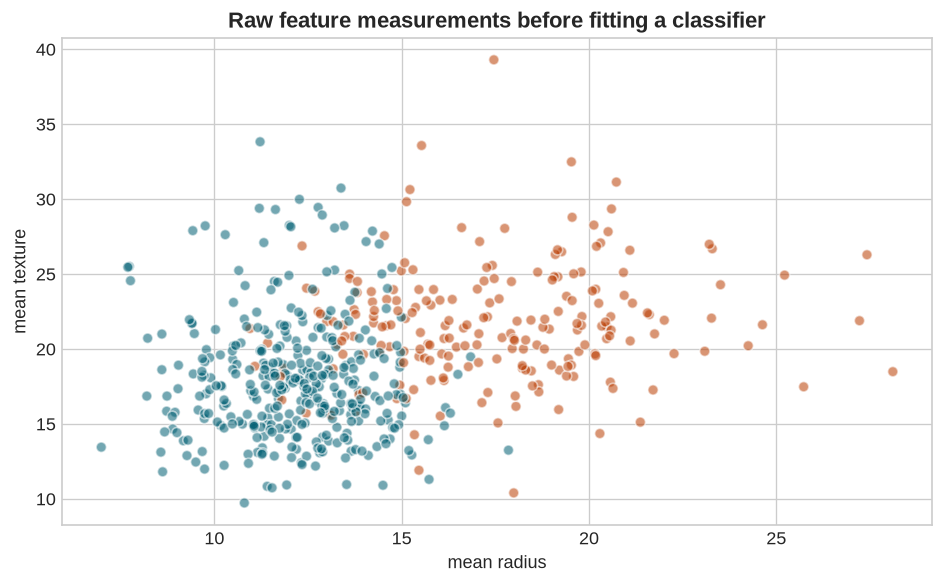

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cancer.frame["mean radius"], cancer.frame["mean texture"], c=cancer.target, cmap=ListedColormap([CORAL, TEAL]), alpha=.55, edgecolor="white", s=38)
ax.set(title="Raw feature measurements before fitting a classifier", xlabel="mean radius", ylabel="mean texture")
plt.tight_layout()

<h2 id="1.-From-a-linear-score-to-a-probability">1. From a linear score to a probability</h2><p>Logistic regression models log-odds as a linear function $z=\beta_0+\beta_1x_1+\cdots$. The sigmoid converts this unbounded score to a probability:</p>
<p>$$P(Y=1|x)=\frac{1}{1+e^{-z}}.$$</p>

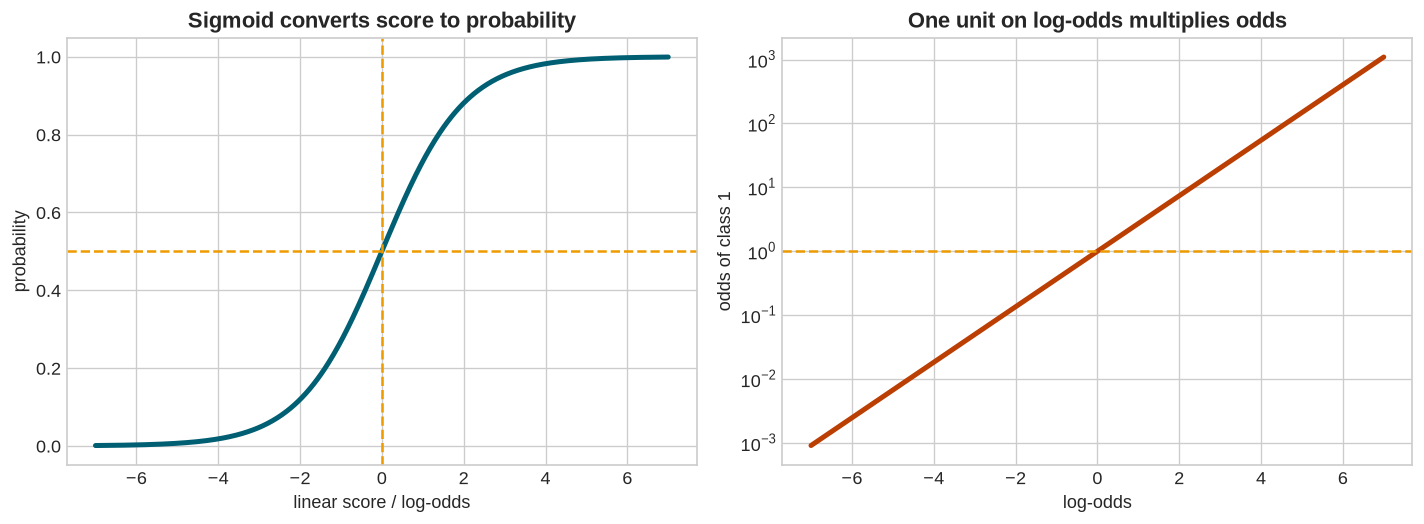

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-7, 7, 600)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(z, sigmoid(z), c=TEAL, lw=3)
axes[0].axhline(.5, ls="--", c=GOLD); axes[0].axvline(0, ls="--", c=GOLD)
axes[0].set(xlabel="linear score / log-odds", ylabel="probability", title="Sigmoid converts score to probability")
odds = np.exp(z)
axes[1].semilogy(z, odds, c=CORAL, lw=3)
axes[1].axhline(1, ls="--", c=GOLD)
axes[1].set(xlabel="log-odds", ylabel="odds of class 1", title="One unit on log-odds multiplies odds")
plt.tight_layout()

<h2 id="2.-Likelihood-and-log-loss">2. Likelihood and log loss</h2><p>When the true class is 1, increasing predicted probability lowers loss. When the true class is 0, the same increase raises loss. This makes a confident wrong prediction expensive.</p>

In [5]:
probability_examples = pd.DataFrame({"true class": [1, 1, 0, 0], "predicted probability of class 1": [.90, .10, .10, .90]})
probability_examples["log loss"] = -(probability_examples["true class"] * np.log(probability_examples["predicted probability of class 1"]) + (1 - probability_examples["true class"]) * np.log(1 - probability_examples["predicted probability of class 1"]))
probability_examples.round(3)

,true class,predicted probability of class 1,log loss
0,1,0.9,0.105
1,1,0.1,2.303
2,0,0.1,0.105
3,0,0.9,2.303


<p>The four rows show why confidence matters. The curve extends the same calculation across every probability from almost 0 to almost 1.</p>

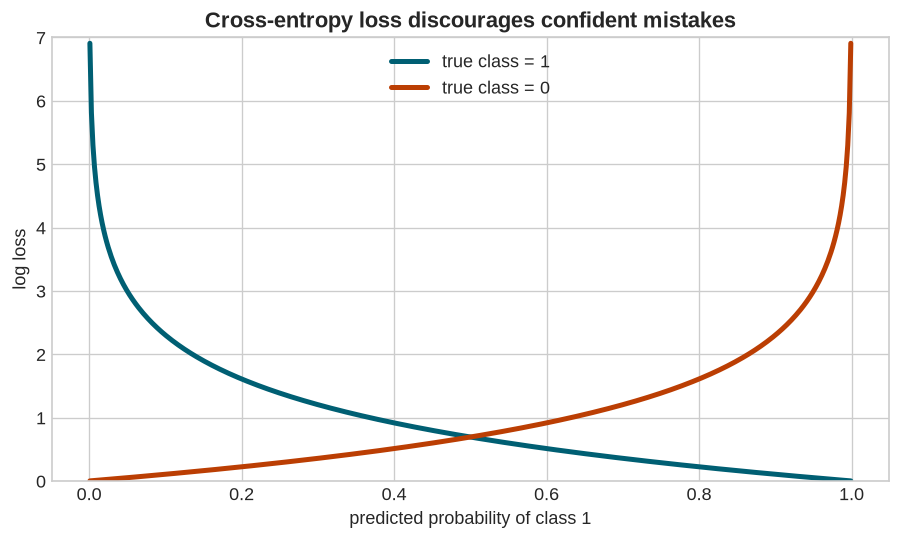

In [6]:
p = np.linspace(.001, .999, 500)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(p, -np.log(p), c=TEAL, lw=3, label="true class = 1")
ax.plot(p, -np.log(1-p), c=CORAL, lw=3, label="true class = 0")
ax.set(ylim=(0, 7), xlabel="predicted probability of class 1", ylabel="log loss", title="Cross-entropy loss discourages confident mistakes")
ax.legend(); plt.show()

<h2 id="3.-Decision-boundary-and-threshold">3. Decision boundary and threshold</h2><p>A linear boundary separates regions of feature space, but a threshold is an action choice. Changing it shifts precision, recall, false positives, and workload.</p>

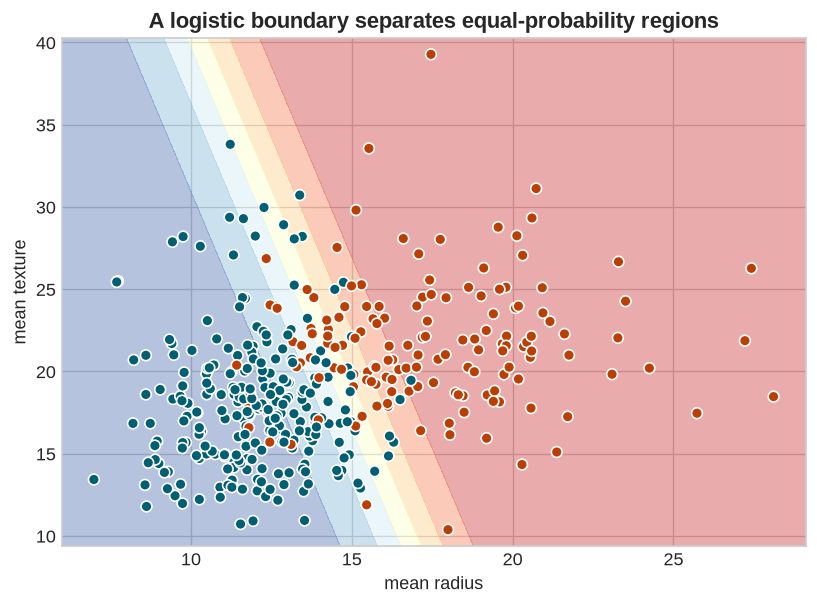

In [7]:
X = cancer.data[["mean radius", "mean texture"]]
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=.30, random_state=301)
logit = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(8, 5.5))
DecisionBoundaryDisplay.from_estimator(logit, X_train, response_method="predict_proba", cmap="RdYlBu", alpha=.38, ax=ax)
ax.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap=ListedColormap([CORAL, TEAL]), edgecolor="white", s=42)
ax.set(title="A logistic boundary separates equal-probability regions", xlabel="mean radius", ylabel="mean texture")
plt.show()

In [8]:
score = logit.predict_proba(X_test)[:, 1]
rows = []
for threshold in [.20, .35, .50, .65, .80]:
    action = score >= threshold
    rows.append({"threshold": threshold, "positive actions": action.sum(), "recall": recall_score(y_test, action), "precision": precision_score(y_test, action)})
threshold_table = pd.DataFrame(rows).set_index("threshold").round(3)
threshold_table

,positive actions,recall,precision
threshold,,,
0.20,127,0.991,0.835
0.35,119,0.953,0.857
0.50,114,0.925,0.868
0.65,102,0.869,0.912
0.80,86,0.766,0.953


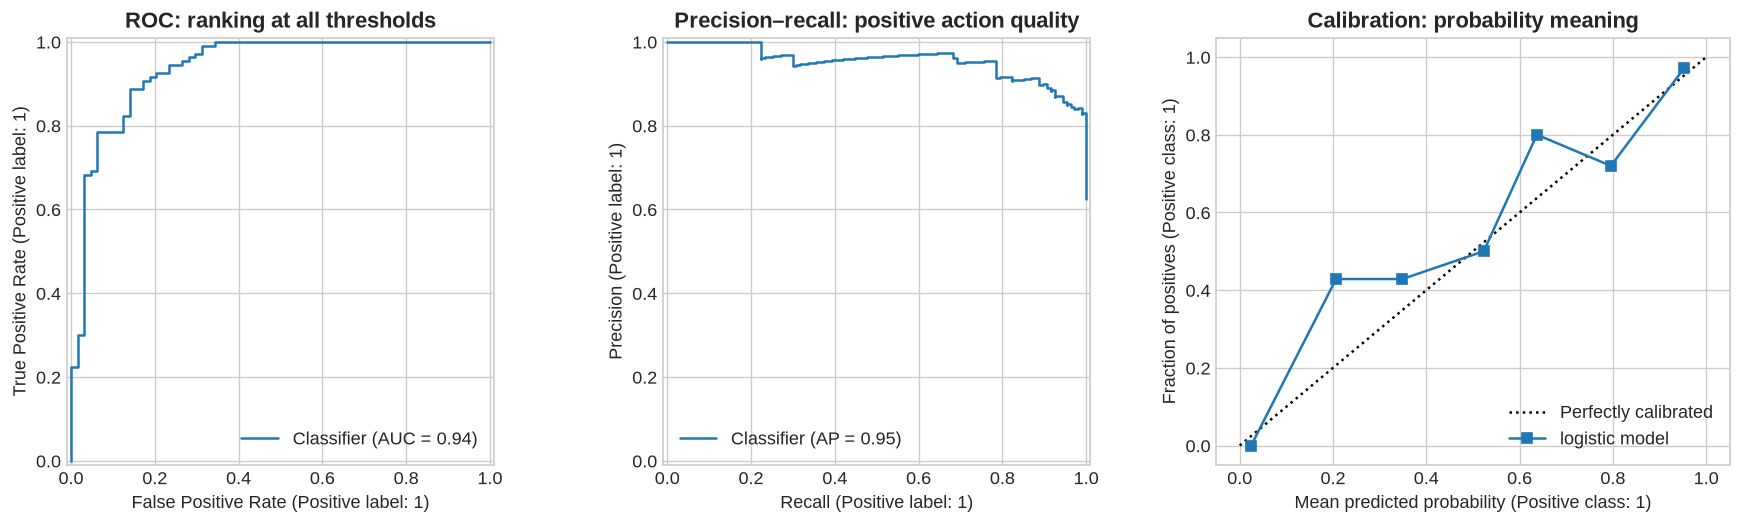

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
RocCurveDisplay.from_predictions(y_test, score, ax=axes[0]); axes[0].set_title("ROC: ranking at all thresholds")
PrecisionRecallDisplay.from_predictions(y_test, score, ax=axes[1]); axes[1].set_title("Precision–recall: positive action quality")
CalibrationDisplay.from_predictions(y_test, score, n_bins=7, name="logistic model", ax=axes[2])
axes[2].set_title("Calibration: probability meaning")
plt.tight_layout()

<h2 id="4.-Confusion-matrix-and-base-rate">4. Confusion matrix and base rate</h2><p>Precision depends on the base rate. The same sensitivity and specificity can result in very different precision when positive cases are rare.</p>

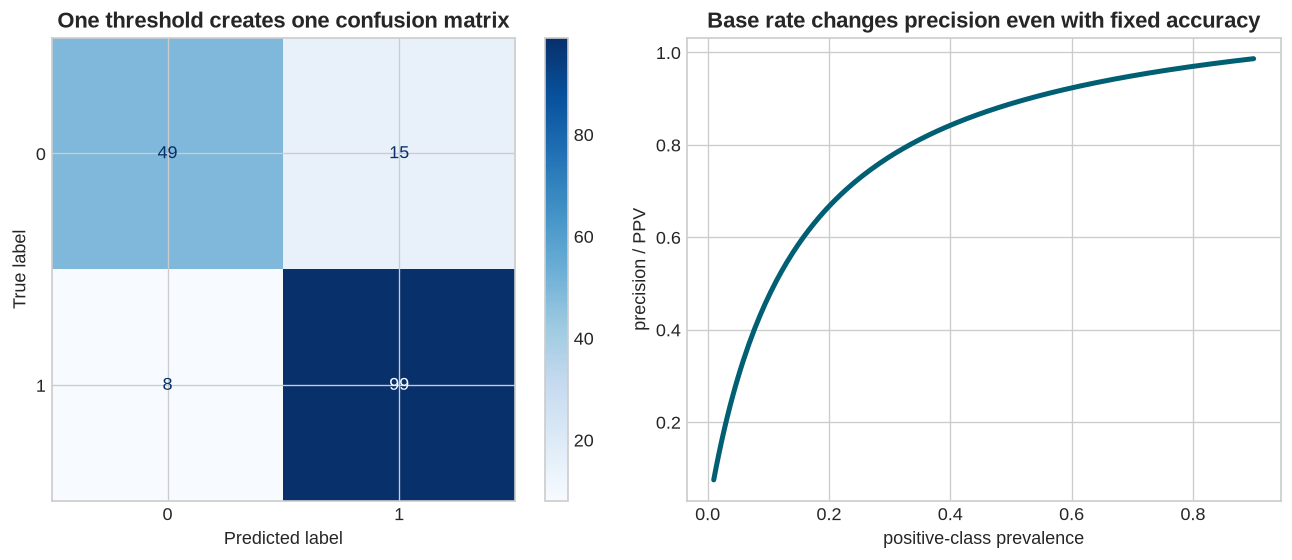

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, score >= .5, cmap="Blues", ax=axes[0])
axes[0].set_title("One threshold creates one confusion matrix")
prevalence = np.linspace(.01, .9, 200); sensitivity, specificity = .80, .90
precision = sensitivity*prevalence / (sensitivity*prevalence + (1-specificity)*(1-prevalence))
axes[1].plot(prevalence, precision, c=TEAL, lw=3)
axes[1].set(xlabel="positive-class prevalence", ylabel="precision / PPV", title="Base rate changes precision even with fixed accuracy")
plt.tight_layout()

<h2 id="5.-k-nearest-neighbours:-local-voting-needs-a-meaningful-distance">5. k-nearest neighbours: local voting needs a meaningful distance</h2><p>Features in incompatible units make raw Euclidean distance misleading. Scaling puts a one-standard-deviation change on a comparable footing.</p>

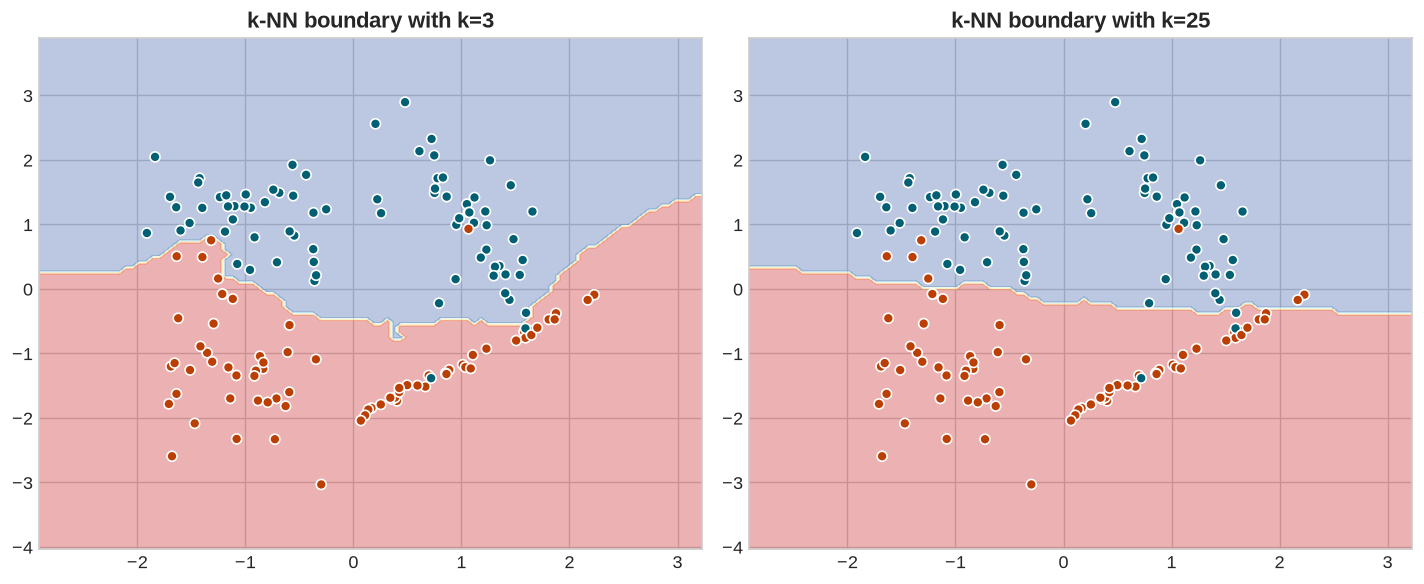

In [11]:
X_knn, y_knn = make_classification(n_samples=150, n_features=2, n_redundant=0, n_informative=2, class_sep=1.1, random_state=301)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, k in zip(axes, [3, 25]):
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_knn, y_knn)
    DecisionBoundaryDisplay.from_estimator(knn, X_knn, response_method="predict", cmap="RdYlBu", alpha=.35, ax=ax)
    ax.scatter(X_knn[:,0], X_knn[:,1], c=y_knn, cmap=ListedColormap([CORAL, TEAL]), edgecolor="white")
    ax.set(title=f"k-NN boundary with k={k}")
plt.tight_layout()

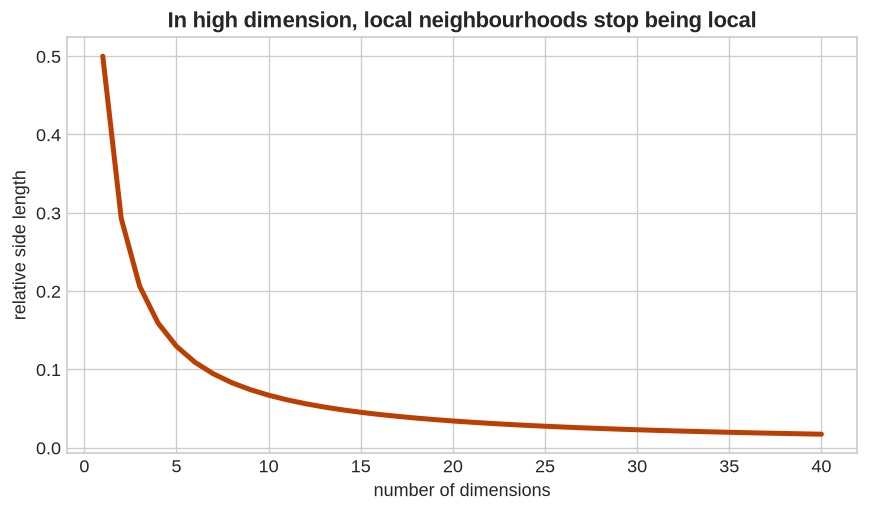

In [12]:
dimension = np.arange(1, 41)
relative_neighbourhood = (1 - .5**(1/dimension))  # illustrative side length needed to contain 50% volume
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(dimension, relative_neighbourhood, c=CORAL, lw=3)
ax.set(xlabel="number of dimensions", ylabel="relative side length", title="In high dimension, local neighbourhoods stop being local")
plt.show()

<h2 id="6.-Naive-Bayes:-update-a-prior-with-evidence">6. Naive Bayes: update a prior with evidence</h2><p>Naive Bayes multiplies likelihood terms under a conditional-independence assumption. We normally compute in log space because many small probabilities underflow.</p>

P(spam | free, urgent) = 0.921


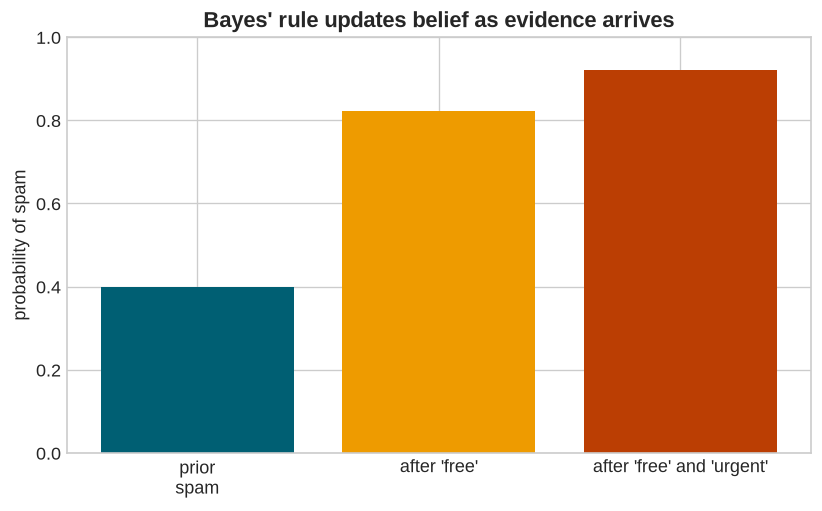

In [13]:
prior_spam = .40
score_spam = prior_spam * .70 * .50
score_nonspam = (1-prior_spam) * .10 * .20
posterior = score_spam / (score_spam + score_nonspam)
print(f"P(spam | free, urgent) = {posterior:.3f}")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(["prior\nspam", "after 'free'", "after 'free' and 'urgent'"], [prior_spam, (.4*.7)/(.4*.7+.6*.1), posterior], color=[TEAL, GOLD, CORAL])
ax.set(ylim=(0,1), ylabel="probability of spam", title="Bayes' rule updates belief as evidence arrives")
plt.show()

<h2 id="7.-Support-vector-machines:-margin-and-kernels">7. Support-vector machines: margin and kernels</h2><p>A soft-margin SVM balances a wide separation margin against violations. A kernel can represent nonlinear boundaries while retaining a linear optimisation in a transformed feature space.</p>

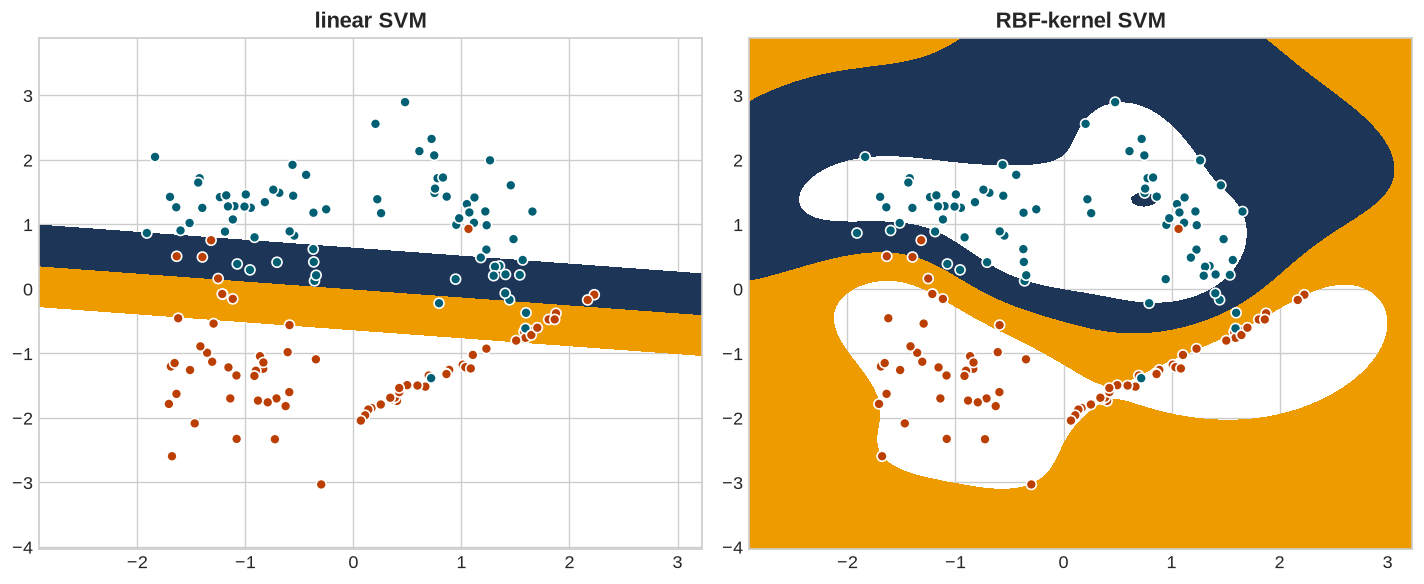

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, label in [
    (axes[0], make_pipeline(StandardScaler(), SVC(kernel="linear", C=.5)), "linear SVM"),
    (axes[1], make_pipeline(StandardScaler(), SVC(kernel="rbf", C=2, gamma=1.2)), "RBF-kernel SVM"),
]:
    model.fit(X_knn, y_knn)
    DecisionBoundaryDisplay.from_estimator(model, X_knn, response_method="decision_function", levels=[-1, 0, 1], colors=[GOLD, INK, GOLD], linestyles=["--", "-", "--"], ax=ax)
    ax.scatter(X_knn[:,0], X_knn[:,1], c=y_knn, cmap=ListedColormap([CORAL, TEAL]), edgecolor="white")
    ax.set_title(label)
plt.tight_layout()

<h2 id="8.-Compare-classifiers-safely">8. Compare classifiers safely</h2><p>Algorithms should use the same split, preprocessing, and evaluation question. High ROC-AUC does not guarantee high precision or calibrated probabilities.</p>

In [15]:
models = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression()),
    "k-NN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    "Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "RBF SVM": CalibratedClassifierCV(make_pipeline(StandardScaler(), SVC(C=1, random_state=301)), ensemble=False),
}
results = []
for name, candidate in models.items():
    candidate.fit(X_train, y_train)
    s = candidate.predict_proba(X_test)[:,1]
    results.append({"model": name, "ROC-AUC": roc_auc_score(y_test, s), "average precision": average_precision_score(y_test, s)})
pd.DataFrame(results).set_index("model").round(3).sort_values("average precision", ascending=False)

,ROC-AUC,average precision
model,,
Naive Bayes,0.944,0.963
logistic,0.939,0.954
k-NN,0.919,0.921
RBF SVM,0.931,0.918


<h2 id="9.-Class-imbalance-and-a-cost-based-threshold">9. Class imbalance and a cost-based threshold</h2><p>If a false negative costs four times a false positive, the simple calibrated-probability threshold is (C_{FP}/(C_{FP}+C_{FN})=0.20). Capacity, interventions, calibration, and subgroup errors can still change the final rule.</p>

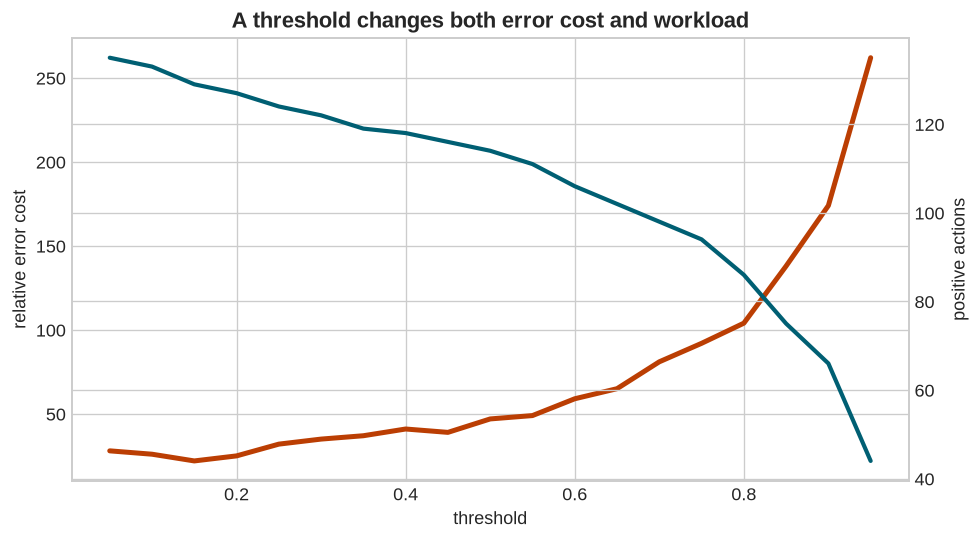

In [16]:
cost_rows = []
for t in np.linspace(.05, .95, 19):
    prediction = score >= t
    fp = ((prediction == 1) & (y_test.to_numpy() == 0)).sum(); fn = ((prediction == 0) & (y_test.to_numpy() == 1)).sum()
    cost_rows.append((t, fp + 4*fn, prediction.sum()))
cost = pd.DataFrame(cost_rows, columns=["threshold", "relative cost", "actions"]).set_index("threshold")
fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.plot(cost.index, cost["relative cost"], c=CORAL, lw=3, label="error cost")
ax1.set(xlabel="threshold", ylabel="relative error cost")
ax2 = ax1.twinx(); ax2.plot(cost.index, cost.actions, c=TEAL, lw=2.5, label="actions")
ax2.set_ylabel("positive actions")
ax1.set_title("A threshold changes both error cost and workload")
plt.show()

<h2 id="Check-your-understanding">Check your understanding</h2><ol>
<li>Why is a 0.50 probability threshold not automatically justified?</li>
<li>Explain how the same classifier can have high ROC-AUC but low precision.</li>
<li>Why must a k-NN pipeline scale its features?</li>
<li>What is the conditional-independence assumption in Naive Bayes?</li>
<li>What extra evidence is needed before a model score becomes an operational action?</li>
</ol>

<h2 id="Applied-classification-lab:-raw-data-to-a-calibrated-action-queue">Applied classification lab: raw data to a calibrated action queue</h2><p>The diagnostic dataset already supplies the raw measurements and recorded class. Here we make the operational sequence visible: inspect two raw variables, fit only on training records, then use held-out probabilities to choose a review capacity.</p>

In [17]:
raw_columns = ["mean radius", "mean texture"]
raw_view = cancer.data[raw_columns].copy().assign(recorded_class=np.where(cancer.target == 1, "benign", "malignant"))
raw_view.head(8)

,mean radius,mean texture,recorded_class
0,17.99,10.38,malignant
1,20.57,17.77,malignant
2,19.69,21.25,malignant
3,11.42,20.38,malignant
4,20.29,14.34,malignant
5,12.45,15.70,malignant
6,18.25,19.98,malignant
7,13.71,20.83,malignant


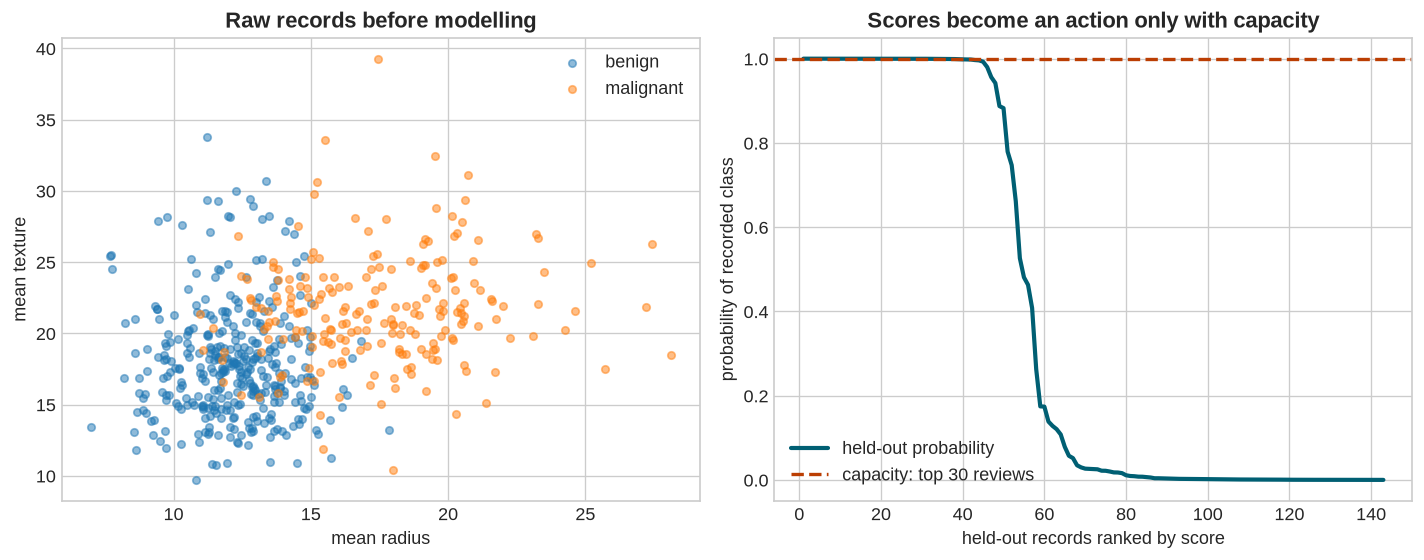

In [18]:
X_case = cancer.data.copy()
y_case = (cancer.target == 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_case, y_case, stratify=y_case, test_size=.25, random_state=301)
case_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_train, y_train)
case_score = case_model.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for label, group in raw_view.groupby("recorded_class"):
    axes[0].scatter(group["mean radius"], group["mean texture"], s=20, alpha=.5, label=label)
axes[0].set(title="Raw records before modelling", xlabel="mean radius", ylabel="mean texture"); axes[0].legend()
ranked = pd.DataFrame({"score": case_score, "recorded class": y_test}).sort_values("score", ascending=False).reset_index(drop=True)
axes[1].plot(ranked.index + 1, ranked.score, color=TEAL, lw=2.5, label="held-out probability")
axes[1].axhline(ranked.score.iloc[29], color=CORAL, lw=2, ls="--", label="capacity: top 30 reviews")
axes[1].set(title="Scores become an action only with capacity", xlabel="held-out records ranked by score", ylabel="probability of recorded class"); axes[1].legend()
plt.tight_layout()

<p>Capacity does not make a threshold correct. A real deployment also needs calibration, benefit and harm evidence, oversight, and population-specific validation.</p>

## Logistic loss in 3D: probability errors across candidate equations

Use real wine measurements and two recorded cultivars. Each row below contains alcohol and its binary label. We reserve test records, scale alcohol on the training set, and fit $p(y=1\mid x)=\sigma(b+wx)$. At each grid location the height is the average training log loss, calculated with `logaddexp` for numerical stability. The minimum can be compared with its contour projection and the resulting sigmoid.

,alcohol,target
0,14.23,0
1,13.20,0
2,13.16,0
3,14.37,0
4,13.24,0
5,14.20,0
6,14.39,0
7,14.06,0
8,14.83,0
9,13.86,0


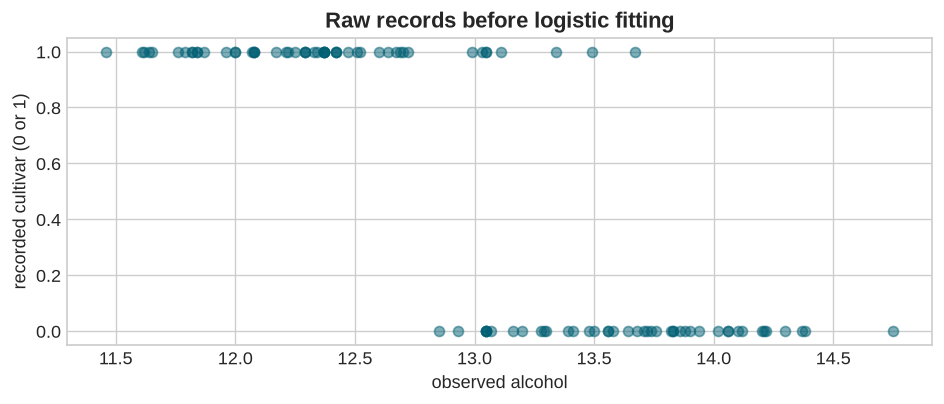

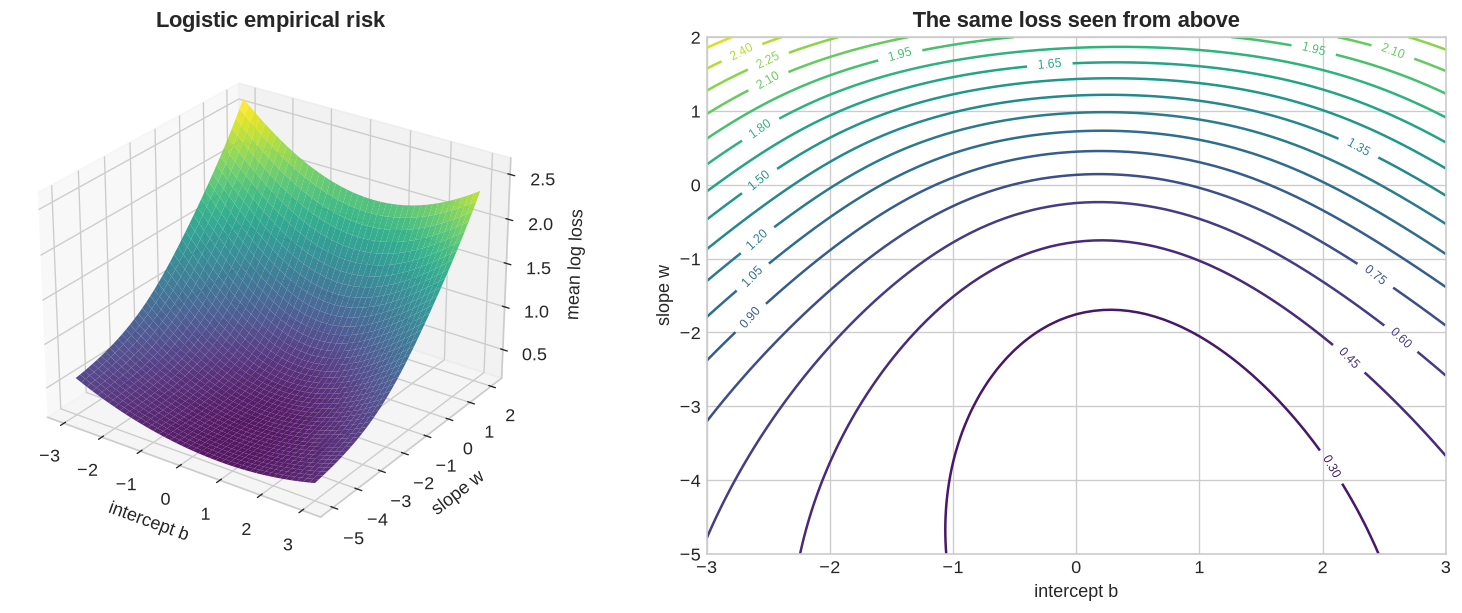

In [19]:
from sklearn.datasets import load_wine
from scipy.special import expit
from IPython.display import display
binary=load_wine(as_frame=True).frame.query('target < 2')[['alcohol','target']]
display(binary.head(10))
binary_train,binary_test=train_test_split(binary,stratify=binary.target,test_size=.25,random_state=301)
fig,ax=plt.subplots(figsize=(8,3.5))
ax.scatter(binary_train.alcohol,binary_train.target,alpha=.5,color='#005F73')
ax.set(xlabel='observed alcohol',ylabel='recorded cultivar (0 or 1)',title='Raw records before logistic fitting'); plt.tight_layout(); plt.show()
binary_scaler=StandardScaler().fit(binary_train[['alcohol']])
binary_x=binary_scaler.transform(binary_train[['alcohol']]).ravel()
binary_y=binary_train.target.to_numpy()
bb,ww=np.meshgrid(np.linspace(-3,3,85),np.linspace(-5,2,85))
logits=bb[...,None]+ww[...,None]*binary_x
log_surface=np.mean(np.logaddexp(0,logits)-binary_y*logits,axis=-1)
fig=plt.figure(figsize=(13,5),layout='constrained')
ax=fig.add_subplot(121,projection='3d')
ax.plot_surface(bb,ww,log_surface,cmap='viridis',alpha=.9,linewidth=0,rasterized=True)
ax.set(xlabel='intercept b',ylabel='slope w',zlabel='mean log loss',title='Logistic empirical risk'); ax.view_init(27,-55)
ax=fig.add_subplot(122)
cs=ax.contour(bb,ww,log_surface,levels=16,cmap='viridis'); ax.clabel(cs,fontsize=7)
ax.set(xlabel='intercept b',ylabel='slope w',title='The same loss seen from above'); plt.show()

The vertical axis describes an average probability penalty, while the original observations are binary labels. Changing a classification threshold leaves this surface unchanged because the probability predictions have not changed. Choosing a threshold is a separate decision step.